# Deep Learning Models for Pneumonia Detection

This notebook implements three deep learning models for pneumonia detection:

1. **CNN** - Custom convolutional neural network with BatchNormalization
2. **VGG16 Fine-Tuned** - Transfer learning with two-phase training
3. **ResNet50 Fine-Tuned** - Transfer learning with two-phase training

## Model Architectures

| Model | Architecture |
|-------|-------------|
| CNN | BatchNormalization after each Conv2D/Dense, progressive dropout (0.25-0.5), L2 regularization |
| VGG16 | Enhanced head (512-256-1), two-phase training with fine-tuning of block5 |
| ResNet50 | Enhanced head (512-256-1), two-phase training with fine-tuning of conv5 block |

---
# Setup and Configuration

In [66]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input,
    BatchNormalization, Activation, GlobalAveragePooling2D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

TensorFlow version: 2.20.0
GPU available: False
Start time: 2026-01-10 19:31:50


In [67]:
# Directory configuration
DATA_DIR = Path('../data/chest_xray')
PREPROCESSING_DIR = Path('../results/preprocessing')
RESULTS_BASE = Path('../results/models')

CNN_RESULTS_DIR = RESULTS_BASE / 'cnn'
VGG16_RESULTS_DIR = RESULTS_BASE / 'vgg16'
RESNET_RESULTS_DIR = RESULTS_BASE / 'resnet50'

for dir_path in [CNN_RESULTS_DIR, VGG16_RESULTS_DIR, RESNET_RESULTS_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"Data directory not found: {DATA_DIR}"
assert PREPROCESSING_DIR.exists(), f"Preprocessing directory not found: {PREPROCESSING_DIR}"

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Results: CNN={CNN_RESULTS_DIR}, VGG16={VGG16_RESULTS_DIR}, ResNet50={RESNET_RESULTS_DIR}")

Data directory: /Users/beatrizfarias/Library/CloudStorage/OneDrive-UniversidadedeAveiro/universidade/5 ano/FAA/Project 2/FAA_Project2/data/chest_xray
Results: CNN=../results/models/cnn, VGG16=../results/models/vgg16, ResNet50=../results/models/resnet50


In [68]:
# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 20
LEARNING_RATE_CNN = 0.001
LEARNING_RATE_TL = 0.0001
LEARNING_RATE_FT = 1e-5

print("Hyperparameters:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}, Batch size: {BATCH_SIZE}")
print(f"  CNN epochs: {EPOCHS}, TL Phase1: {EPOCHS_PHASE1}, Phase2: {EPOCHS_PHASE2}")

Hyperparameters:
  Image size: 224x224, Batch size: 32
  CNN epochs: 50, TL Phase1: 15, Phase2: 20


In [69]:
# Load class weights
class_weights_path = PREPROCESSING_DIR / 'class_weights.npy'
if class_weights_path.exists():
    class_weights_array = np.load(class_weights_path)
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}
    print(f"Class weights loaded: {class_weight_dict}")
else:
    class_weight_dict = {0: 1.9448, 1: 0.6730}
    print(f"Using default class weights: {class_weight_dict}")

Class weights loaded: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


---
# Data Loading

In [70]:
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, width_shift_range=0.1,
    height_shift_range=0.1, shear_range=0.1, zoom_range=0.1,
    horizontal_flip=True, fill_mode='nearest', validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', subset='training', shuffle=True, seed=42
)
val_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', subset='validation', shuffle=False, seed=42
)
test_generator = test_datagen.flow_from_directory(
    DATA_DIR / 'test', target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print(f"Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train: 4173, Val: 1043, Test: 624


---
# Helper Functions

In [71]:
def save_history(history, results_dir, filename='training_history.json'):
    """Save training history to JSON immediately after training."""
    try:
        history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
        with open(Path(results_dir) / filename, 'w') as f:
            json.dump(history_dict, f, indent=2)
        print(f"History saved to: {results_dir}/{filename}")
        return True
    except Exception as e:
        print(f"Warning: Could not save history: {e}")
        return False

In [72]:
def plot_history(history, title, save_path=None, phase2_start=None):
    """Plot training history. Saves BEFORE show(). Wrapped in try-except."""
    try:
        hist = history.history if hasattr(history, 'history') else history
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        epochs = range(1, len(hist['accuracy']) + 1)
        
        axes[0].plot(epochs, hist['accuracy'], 'b-', label='Training', linewidth=2)
        axes[0].plot(epochs, hist['val_accuracy'], 'r-', label='Validation', linewidth=2)
        if phase2_start:
            axes[0].axvline(x=phase2_start, color='green', linestyle='--', label=f'Fine-tuning (epoch {phase2_start})')
        axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(epochs, hist['loss'], 'b-', label='Training', linewidth=2)
        axes[1].plot(epochs, hist['val_loss'], 'r-', label='Validation', linewidth=2)
        if phase2_start:
            axes[1].axvline(x=phase2_start, color='green', linestyle='--', label=f'Fine-tuning (epoch {phase2_start})')
        axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Plot saved: {save_path}")
        plt.show(); plt.close()
    except Exception as e:
        print(f"Warning: Plot failed: {e}")
        plt.close('all')

In [73]:
def plot_confusion(y_true, y_pred, title, save_path=None):
    """Plot confusion matrix. Saves BEFORE show(). Wrapped in try-except."""
    try:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['NORMAL', 'PNEUMONIA'], yticklabels=['NORMAL', 'PNEUMONIA'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title, fontweight='bold')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"Confusion matrix saved: {save_path}")
        plt.show(); plt.close()
    except Exception as e:
        print(f"Warning: Confusion matrix failed: {e}")
        plt.close('all')

In [74]:
def evaluate_model(model, generator, model_name):
    """Evaluate model and return metrics."""
    generator.reset()
    y_pred_proba = model.predict(generator, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    y_true = generator.classes
    
    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc_roc': roc_auc_score(y_true, y_pred_proba)
    }
    
    print(f"\n{'='*50}\n{model_name} - Test Results\n{'='*50}")
    print(f"Accuracy: {metrics['accuracy']:.4f}, Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}, F1: {metrics['f1']:.4f}, AUC: {metrics['auc_roc']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))
    
    return metrics, y_true, y_pred

In [75]:
def combine_histories(h1, h2):
    """Combine two training histories."""
    try:
        hist1 = h1.history if hasattr(h1, 'history') else h1
        hist2 = h2.history if hasattr(h2, 'history') else h2
        return {k: hist1[k] + hist2.get(k, []) for k in hist1.keys()}
    except Exception as e:
        print(f"Warning: Could not combine histories: {e}")
        return None

---
# Part 1: CNN

In [76]:
def create_cnn(input_shape=(224, 224, 3)):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        Conv2D(32, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        MaxPooling2D((2,2)), Dropout(0.25),
        
        Conv2D(64, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        Conv2D(64, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        MaxPooling2D((2,2)), Dropout(0.25),
        
        Conv2D(128, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        Conv2D(128, (3,3), padding='same'), BatchNormalization(), Activation('relu'),
        MaxPooling2D((2,2)), Dropout(0.25),
        
        Flatten(),
        Dense(256, kernel_regularizer=l2(0.001)), BatchNormalization(), Activation('relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name='CNN')
    
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE_CNN), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
    return model

model_cnn = create_cnn()
print("CNN created")
model_cnn.summary()

CNN created


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_43 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_44 (Activation)      │ (None, 56, 56, 128)    │             

 Total params: 25,980,449 (99.11 MB)

 Trainable params: 25,979,041 (99.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [77]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(CNN_RESULTS_DIR / 'best_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

In [78]:
print("="*60 + f"\nTRAINING CNN\nStart: {datetime.now()}\n" + "="*60)

cnn_history = model_cnn.fit(
    train_generator, epochs=EPOCHS, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=cnn_callbacks, verbose=1
)

# SAVE HISTORY IMMEDIATELY
save_history(cnn_history, CNN_RESULTS_DIR)
print(f"CNN training done: {datetime.now()}")

TRAINING CNN
Start: 2026-01-10 19:31:50.967302
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8360 - loss: 1.3029 - precision_9: 0.9611 - recall_9: 0.8120
Epoch 1: val_loss improved from None to 2.85140, saving model to ../results/models/cnn/best_model.keras

Epoch 1: finished saving model to ../results/models/cnn/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.8807 - loss: 1.2121 - precision_9: 0.9666 - recall_9: 0.8694 - val_accuracy: 0.7430 - val_loss: 2.8514 - val_precision_9: 0.7430 - val_recall_9: 1.0000 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9076 - loss: 0.8757 - precision_9: 0.9704 - recall_9: 0.9031
Epoch 2: val_loss improved from 2.85140 to 1.43333, saving model to ../results/models/cnn/best_model.keras

Epoch 2: finished saving model to ../results/models/cnn/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.9094 - loss: 0.7947 - precision_9: 0.9736 - recall_9: 

Plot saved: ../results/models/cnn/training_history.png


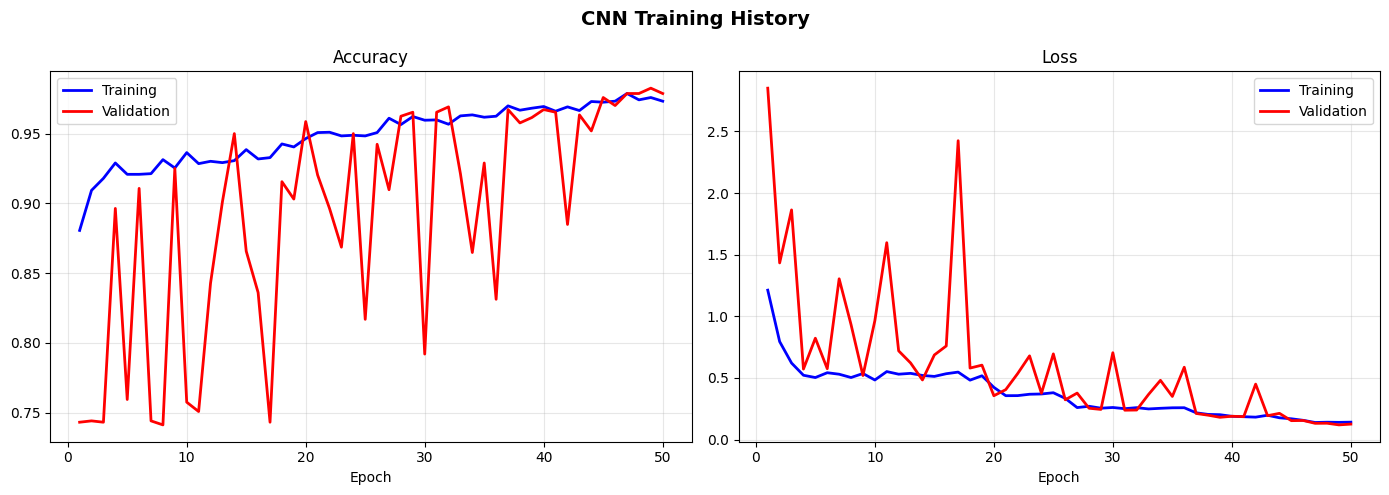

In [79]:
plot_history(cnn_history, 'CNN Training History', save_path=CNN_RESULTS_DIR / 'training_history.png')

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 368ms/step

CNN - Test Results
Accuracy: 0.9054, Precision: 0.9190
Recall: 0.9308, F1: 0.9248, AUC: 0.9510
              precision    recall  f1-score   support

      NORMAL       0.88      0.86      0.87       234
   PNEUMONIA       0.92      0.93      0.92       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

Confusion matrix saved: ../results/models/cnn/confusion_matrix.png


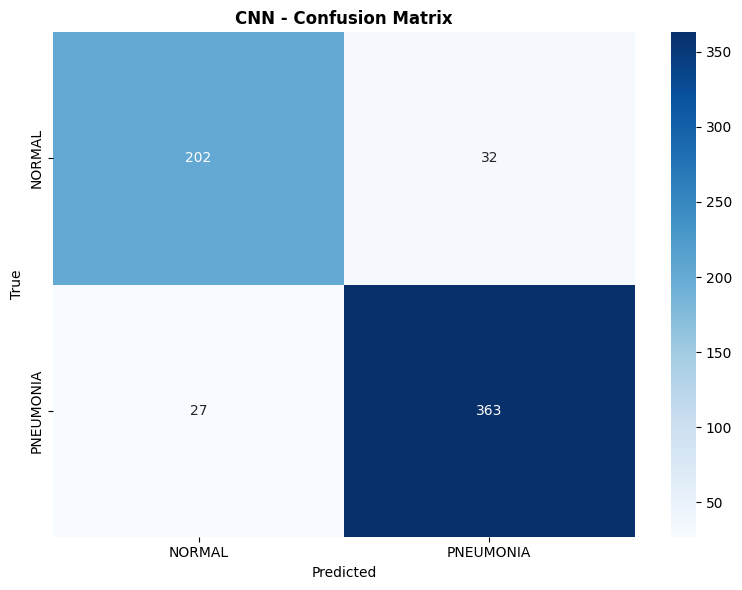

In [80]:
cnn_metrics, cnn_y_true, cnn_y_pred = evaluate_model(model_cnn, test_generator, 'CNN')
plot_confusion(cnn_y_true, cnn_y_pred, 'CNN - Confusion Matrix', save_path=CNN_RESULTS_DIR / 'confusion_matrix.png')

In [81]:
try:
    with open(CNN_RESULTS_DIR / 'model_summary.txt', 'w') as f:
        f.write("CNN - MODEL SUMMARY\n" + "="*60 + "\n")
        model_cnn.summary(print_fn=lambda x: f.write(x + '\n'))
        f.write(f"\nTEST METRICS\n" + "-"*40 + "\n")
        for k, v in cnn_metrics.items():
            if k != 'model_name': f.write(f"{k}: {v:.4f}\n")
    print(f"Summary saved: {CNN_RESULTS_DIR / 'model_summary.txt'}")
except Exception as e:
    print(f"Warning: {e}")

Summary saved: ../results/models/cnn/model_summary.txt


---
# Part 2: VGG16 Fine-Tuned

In [82]:
def create_vgg16(input_shape=(224, 224, 3)):
    vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    vgg_base.trainable = False
    
    model = Sequential([
        vgg_base,
        GlobalAveragePooling2D(),
        Dense(512), BatchNormalization(), Activation('relu'), Dropout(0.5),
        Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='VGG16_FineTuned')
    
    return model, vgg_base

model_vgg16, vgg16_base = create_vgg16()
print("VGG16 created!")
model_vgg16.summary()

VGG16 created!


Model: "VGG16_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_46 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_47 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,001 (57.65 MB)

 Trainable params: 395,777 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [83]:
model_vgg16.compile(optimizer=Adam(learning_rate=LEARNING_RATE_TL), loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

vgg16_callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(VGG16_RESULTS_DIR / 'phase1_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

In [84]:
print("="*60 + f"\nVGG16 PHASE 1: Training Head\nStart: {datetime.now()}\n" + "="*60)

vgg16_history_p1 = model_vgg16.fit(
    train_generator, epochs=EPOCHS_PHASE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=vgg16_callbacks_p1, verbose=1
)

# SAVE HISTORY IMMEDIATELY
save_history(vgg16_history_p1, VGG16_RESULTS_DIR, 'phase1_history.json')
phase1_epochs = len(vgg16_history_p1.history['accuracy'])
print(f"Phase 1 done: {phase1_epochs} epochs")

VGG16 PHASE 1: Training Head
Start: 2026-01-10 22:37:47.718399
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7932 - loss: 0.4560 - precision_10: 0.9156 - recall_10: 0.7971
Epoch 1: val_loss improved from None to 0.52620, saving model to ../results/models/vgg16/phase1_model.keras

Epoch 1: finished saving model to ../results/models/vgg16/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 333s 3s/step - accuracy: 0.8294 - loss: 0.3676 - precision_10: 0.9506 - recall_10: 0.8126 - val_accuracy: 0.8840 - val_loss: 0.5262 - val_precision_10: 0.8838 - val_recall_10: 0.9716 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8813 - loss: 0.2841 - precision_10: 0.9738 - recall_10: 0.8623
Epoch 2: val_loss improved from 0.52620 to 0.38928, saving model to ../results/models/vgg16/phase1_model.keras

Epoch 2: finished saving model to ../results/models/vgg16/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.8862 - los

In [85]:
# Unfreeze block5
vgg16_base.trainable = True
for layer in vgg16_base.layers:
    layer.trainable = 'block5' in layer.name

model_vgg16.compile(optimizer=Adam(learning_rate=LEARNING_RATE_FT), loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

vgg16_callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(VGG16_RESULTS_DIR / 'finetuned_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-8, verbose=1)
]
print("VGG16 block5 unfrozen for fine-tuning")

VGG16 block5 unfrozen for fine-tuning


In [86]:
print("="*60 + f"\nVGG16 PHASE 2: Fine-Tuning\nStart: {datetime.now()}\n" + "="*60)

vgg16_history_p2 = model_vgg16.fit(
    train_generator, epochs=EPOCHS_PHASE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=vgg16_callbacks_p2, verbose=1
)

# SAVE HISTORY IMMEDIATELY
save_history(vgg16_history_p2, VGG16_RESULTS_DIR, 'phase2_history.json')
phase2_epochs = len(vgg16_history_p2.history['accuracy'])
print(f"Phase 2 done: {phase2_epochs} epochs, Total: {phase1_epochs + phase2_epochs}")

VGG16 PHASE 2: Fine-Tuning
Start: 2026-01-10 23:56:31.032710
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9398 - loss: 0.1521 - precision_11: 0.9870 - recall_11: 0.9310
Epoch 1: val_loss improved from None to 0.08602, saving model to ../results/models/vgg16/finetuned_model.keras

Epoch 1: finished saving model to ../results/models/vgg16/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.9422 - loss: 0.1450 - precision_11: 0.9884 - recall_11: 0.9332 - val_accuracy: 0.9626 - val_loss: 0.0860 - val_precision_11: 0.9920 - val_recall_11: 0.9574 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9531 - loss: 0.1197 - precision_11: 0.9869 - recall_11: 0.9496
Epoch 2: val_loss did not improve from 0.08602
131/131 ━━━━━━━━━━━━━━━━━━━━ 360s 3s/step - accuracy: 0.9561 - loss: 0.1112 - precision_11: 0.9889 - recall_11: 0.9516 - val_accuracy: 0.9521 - val_loss: 0.1579 - val_precision_11: 0.9932 - val_recall_11:

Plot saved: ../results/models/vgg16/training_history.png


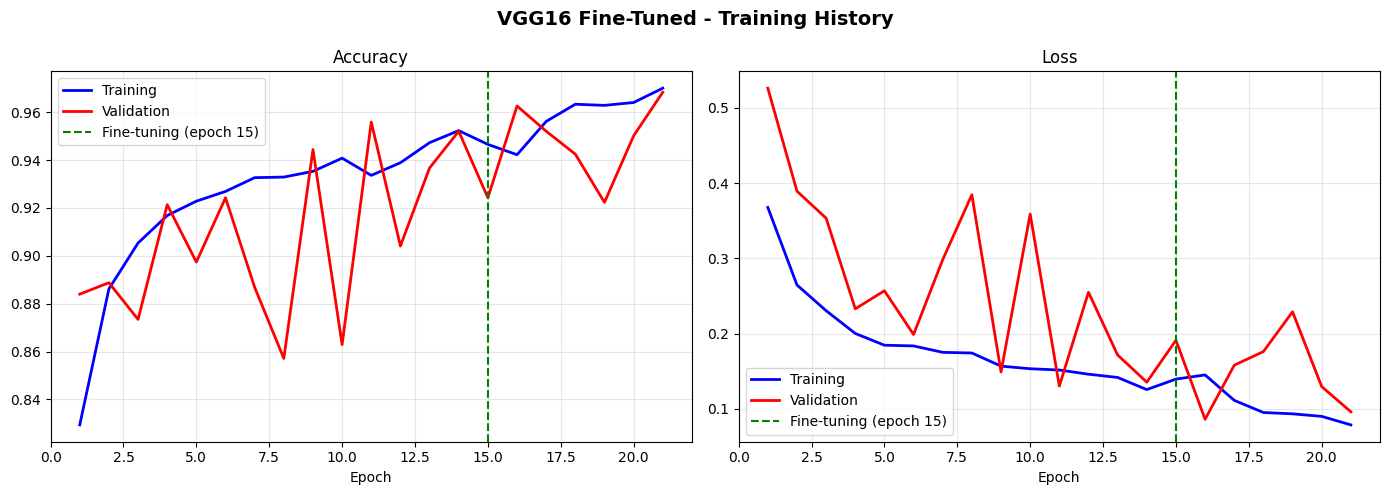

In [87]:
vgg16_combined = combine_histories(vgg16_history_p1, vgg16_history_p2)
if vgg16_combined:
    try:
        with open(VGG16_RESULTS_DIR / 'training_history.json', 'w') as f:
            json.dump({k: [float(v) for v in vals] for k, vals in vgg16_combined.items()}, f, indent=2)
    except: pass
    plot_history(vgg16_combined, 'VGG16 Fine-Tuned - Training History', 
                 save_path=VGG16_RESULTS_DIR / 'training_history.png', phase2_start=phase1_epochs)
else:
    plot_history(vgg16_history_p2, 'VGG16 Fine-Tuned - Phase 2', save_path=VGG16_RESULTS_DIR / 'training_history.png')

20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step

VGG16 Fine-Tuned - Test Results
Accuracy: 0.9151, Precision: 0.8928
Recall: 0.9821, F1: 0.9353, AUC: 0.9570
              precision    recall  f1-score   support

      NORMAL       0.96      0.80      0.88       234
   PNEUMONIA       0.89      0.98      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.89      0.91       624
weighted avg       0.92      0.92      0.91       624

Confusion matrix saved: ../results/models/vgg16/confusion_matrix.png


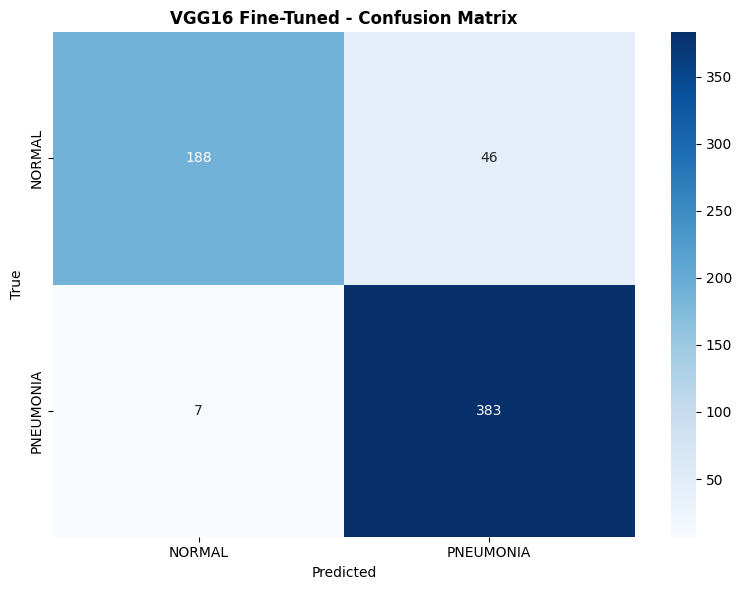

In [88]:
vgg16_metrics, vgg16_y_true, vgg16_y_pred = evaluate_model(model_vgg16, test_generator, 'VGG16 Fine-Tuned')
plot_confusion(vgg16_y_true, vgg16_y_pred, 'VGG16 Fine-Tuned - Confusion Matrix', 
               save_path=VGG16_RESULTS_DIR / 'confusion_matrix.png')

In [89]:
try:
    with open(VGG16_RESULTS_DIR / 'model_summary.txt', 'w') as f:
        f.write(f"VGG16 FINE-TUNED\n" + "="*60 + "\n")
        f.write(f"Phase 1: {phase1_epochs} epochs, Phase 2: {phase2_epochs} epochs\n\n")
        model_vgg16.summary(print_fn=lambda x: f.write(x + '\n'))
        f.write(f"\nTEST METRICS\n" + "-"*40 + "\n")
        for k, v in vgg16_metrics.items():
            if k != 'model_name': f.write(f"{k}: {v:.4f}\n")
except Exception as e:
    print(f"Warning: {e}")

---
# Part 3: ResNet50 Fine-Tuned

In [90]:
def create_resnet50(input_shape=(224, 224, 3)):
    resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    resnet_base.trainable = False
    
    model = Sequential([
        resnet_base,
        GlobalAveragePooling2D(),
        Dense(512), BatchNormalization(), Activation('relu'), Dropout(0.5),
        Dense(256), BatchNormalization(), Activation('relu'), Dropout(0.3),
        Dense(1, activation='sigmoid')
    ], name='ResNet50_FineTuned')
    
    return model, resnet_base

model_resnet50, resnet50_base = create_resnet50()
print("ResNet50 created!")
model_resnet50.summary()

ResNet50 created!


Model: "ResNet50_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_48 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_49 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,771,457 (94.50 MB)

 Trainable params: 1,182,209 (4.51 MB)

 Non-trainable params: 23,589,248 (89.99 MB)

In [91]:
model_resnet50.compile(optimizer=Adam(learning_rate=LEARNING_RATE_TL), loss='binary_crossentropy',
                       metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

resnet_callbacks_p1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(RESNET_RESULTS_DIR / 'phase1_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

In [92]:
print("="*60 + f"\nRESNET50 PHASE 1: Training Head\nStart: {datetime.now()}\n" + "="*60)

resnet_history_p1 = model_resnet50.fit(
    train_generator, epochs=EPOCHS_PHASE1, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=resnet_callbacks_p1, verbose=1
)

# SAVE HISTORY IMMEDIATELY
save_history(resnet_history_p1, RESNET_RESULTS_DIR, 'phase1_history.json')
resnet_phase1_epochs = len(resnet_history_p1.history['accuracy'])
print(f"Phase 1 done: {resnet_phase1_epochs} epochs")

RESNET50 PHASE 1: Training Head
Start: 2026-01-11 00:33:17.055088
Epoch 1/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.6405 - loss: 0.5908 - precision_12: 0.9451 - recall_12: 0.5510
Epoch 1: val_loss improved from None to 0.76545, saving model to ../results/models/resnet50/phase1_model.keras

Epoch 1: finished saving model to ../results/models/resnet50/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 758ms/step - accuracy: 0.7189 - loss: 0.5194 - precision_12: 0.9590 - recall_12: 0.6494 - val_accuracy: 0.2570 - val_loss: 0.7655 - val_precision_12: 0.0000e+00 - val_recall_12: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8089 - loss: 0.3977 - precision_12: 0.9661 - recall_12: 0.7695
Epoch 2: val_loss improved from 0.76545 to 0.64697, saving model to ../results/models/resnet50/phase1_model.keras

Epoch 2: finished saving model to ../results/models/resnet50/phase1_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 7

In [93]:
# Unfreeze conv5
resnet50_base.trainable = True
for layer in resnet50_base.layers:
    layer.trainable = 'conv5' in layer.name

model_resnet50.compile(optimizer=Adam(learning_rate=LEARNING_RATE_FT), loss='binary_crossentropy',
                       metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

resnet_callbacks_p2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(RESNET_RESULTS_DIR / 'finetuned_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-8, verbose=1)
]
print("ResNet50 conv5 unfrozen for fine-tuning")

ResNet50 conv5 unfrozen for fine-tuning


In [94]:
print("="*60 + f"\nRESNET50 PHASE 2: Fine-Tuning\nStart: {datetime.now()}\n" + "="*60)

resnet_history_p2 = model_resnet50.fit(
    train_generator, epochs=EPOCHS_PHASE2, validation_data=val_generator,
    class_weight=class_weight_dict, callbacks=resnet_callbacks_p2, verbose=1
)

# SAVE HISTORY IMMEDIATELY
save_history(resnet_history_p2, RESNET_RESULTS_DIR, 'phase2_history.json')
resnet_phase2_epochs = len(resnet_history_p2.history['accuracy'])
print(f"Phase 2 done: {resnet_phase2_epochs} epochs, Total: {resnet_phase1_epochs + resnet_phase2_epochs}")

RESNET50 PHASE 2: Fine-Tuning
Start: 2026-01-11 00:57:55.177152
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.8559 - loss: 0.3886 - precision_13: 0.9343 - recall_13: 0.8682
Epoch 1: val_loss improved from None to 1.50298, saving model to ../results/models/resnet50/finetuned_model.keras

Epoch 1: finished saving model to ../results/models/resnet50/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8713 - loss: 0.3220 - precision_13: 0.9559 - recall_13: 0.8668 - val_accuracy: 0.7430 - val_loss: 1.5030 - val_precision_13: 0.7430 - val_recall_13: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 899ms/step - accuracy: 0.8864 - loss: 0.2609 - precision_13: 0.9651 - recall_13: 0.8810
Epoch 2: val_loss improved from 1.50298 to 0.91480, saving model to ../results/models/resnet50/finetuned_model.keras

Epoch 2: finished saving model to ../results/models/resnet50/finetuned_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 137s 1

Plot saved: ../results/models/resnet50/training_history.png


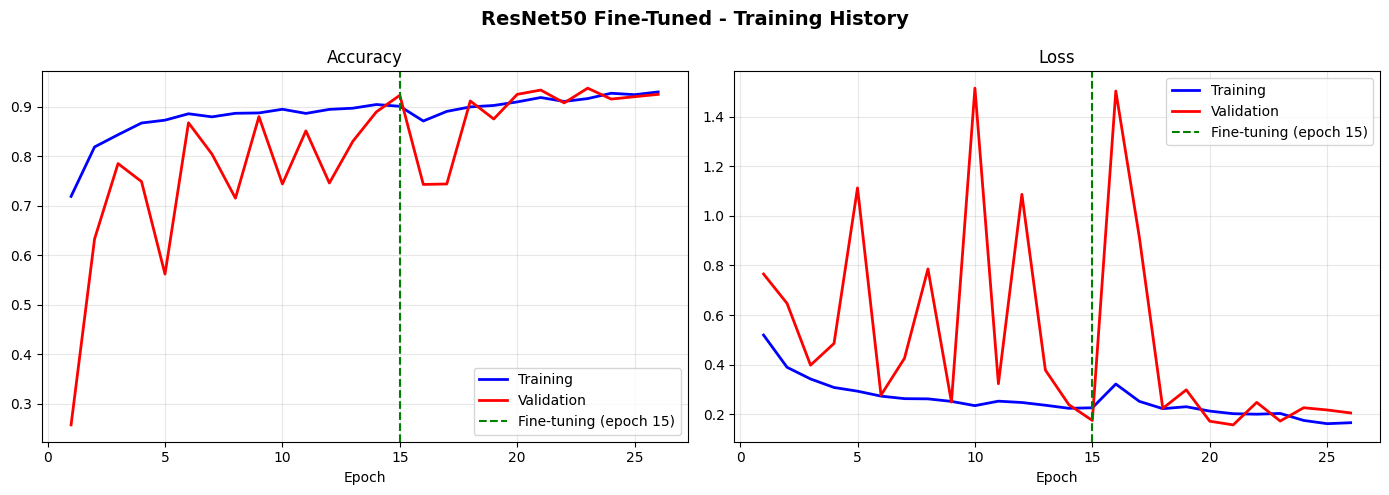

In [95]:
resnet_combined = combine_histories(resnet_history_p1, resnet_history_p2)
if resnet_combined:
    try:
        with open(RESNET_RESULTS_DIR / 'training_history.json', 'w') as f:
            json.dump({k: [float(v) for v in vals] for k, vals in resnet_combined.items()}, f, indent=2)
    except: pass
    plot_history(resnet_combined, 'ResNet50 Fine-Tuned - Training History',
                 save_path=RESNET_RESULTS_DIR / 'training_history.png', phase2_start=resnet_phase1_epochs)
else:
    plot_history(resnet_history_p2, 'ResNet50 Fine-Tuned - Phase 2', save_path=RESNET_RESULTS_DIR / 'training_history.png')

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 615ms/step

ResNet50 Fine-Tuned - Test Results
Accuracy: 0.8173, Precision: 0.7794
Recall: 0.9872, F1: 0.8710, AUC: 0.9428
              precision    recall  f1-score   support

      NORMAL       0.96      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624

Confusion matrix saved: ../results/models/resnet50/confusion_matrix.png


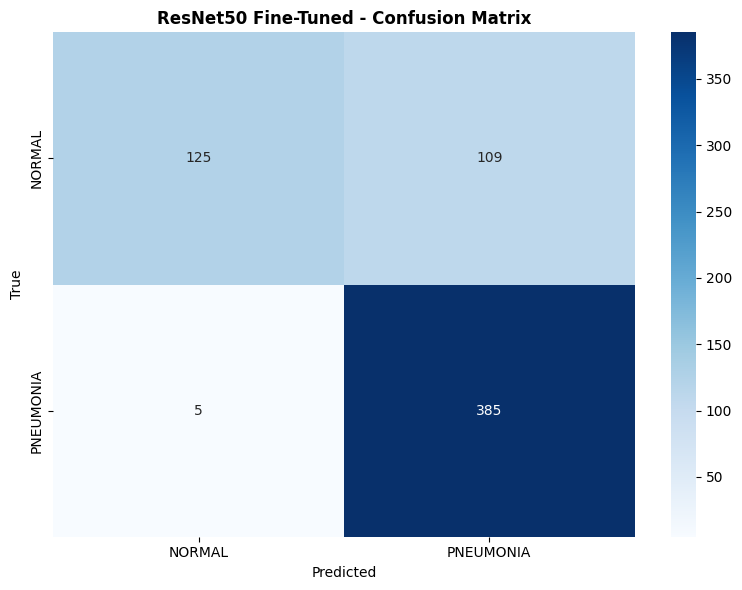

In [96]:
resnet_metrics, resnet_y_true, resnet_y_pred = evaluate_model(model_resnet50, test_generator, 'ResNet50 Fine-Tuned')
plot_confusion(resnet_y_true, resnet_y_pred, 'ResNet50 Fine-Tuned - Confusion Matrix',
               save_path=RESNET_RESULTS_DIR / 'confusion_matrix.png')

In [97]:
try:
    with open(RESNET_RESULTS_DIR / 'model_summary.txt', 'w') as f:
        f.write(f"RESNET50 FINE-TUNED\n" + "="*60 + "\n")
        f.write(f"Phase 1: {resnet_phase1_epochs} epochs, Phase 2: {resnet_phase2_epochs} epochs\n\n")
        model_resnet50.summary(print_fn=lambda x: f.write(x + '\n'))
        f.write(f"\nTEST METRICS\n" + "-"*40 + "\n")
        for k, v in resnet_metrics.items():
            if k != 'model_name': f.write(f"{k}: {v:.4f}\n")
except Exception as e:
    print(f"Warning: {e}")

---
# Part 4: Model Comparison

In [98]:
comparison_df = pd.DataFrame([cnn_metrics, vgg16_metrics, resnet_metrics]).set_index('model_name')

print("="*70 + "\nMODEL COMPARISON\n" + "="*70)
print(comparison_df.round(4).to_string())
print("="*70)

MODEL COMPARISON
                     accuracy  precision  recall      f1  auc_roc
model_name                                                       
CNN                    0.9054     0.9190  0.9308  0.9248   0.9510
VGG16 Fine-Tuned       0.9151     0.8928  0.9821  0.9353   0.9570
ResNet50 Fine-Tuned    0.8173     0.7794  0.9872  0.8710   0.9428


Saved: ../results/models/model_comparison.png


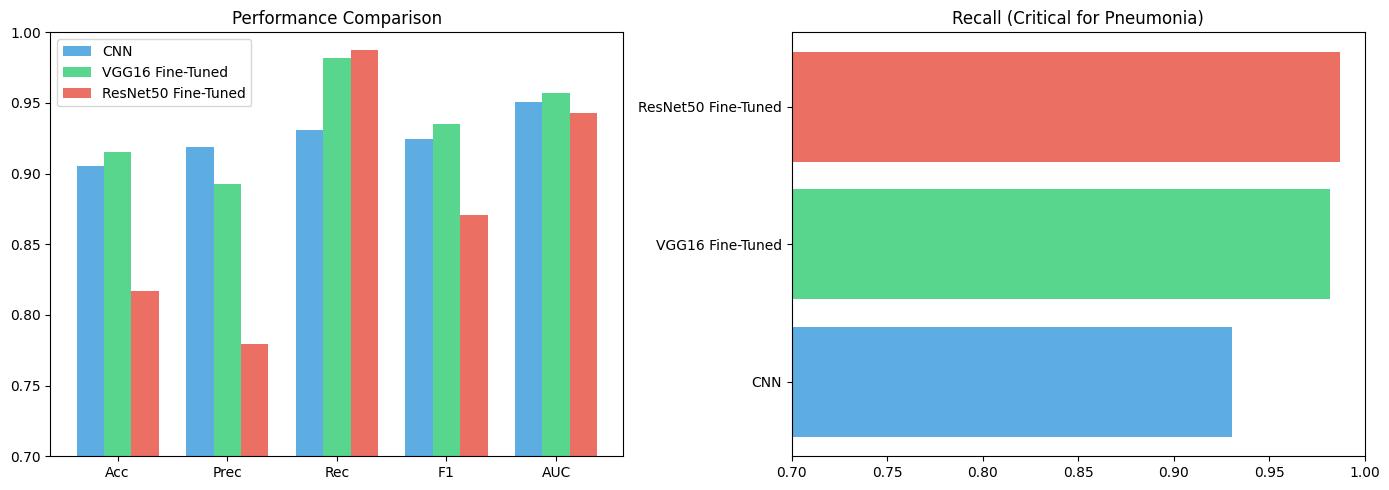

In [99]:
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
    x = np.arange(len(metrics_to_plot))
    width = 0.25
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    
    for i, model in enumerate(comparison_df.index):
        vals = [comparison_df.loc[model, m] for m in metrics_to_plot]
        axes[0].bar(x + i*width, vals, width, label=model, color=colors[i], alpha=0.8)
    axes[0].set_xticks(x + width); axes[0].set_xticklabels(['Acc', 'Prec', 'Rec', 'F1', 'AUC'])
    axes[0].set_ylim([0.7, 1.0]); axes[0].legend(); axes[0].set_title('Performance Comparison')
    
    recall_vals = [comparison_df.loc[m, 'recall'] for m in comparison_df.index]
    axes[1].barh(comparison_df.index, recall_vals, color=colors, alpha=0.8)
    axes[1].set_xlim([0.7, 1.0]); axes[1].set_title('Recall (Critical for Pneumonia)')
    
    plt.tight_layout()
    plt.savefig(RESULTS_BASE / 'model_comparison.png', dpi=150, bbox_inches='tight')
    print(f"Saved: {RESULTS_BASE / 'model_comparison.png'}")
    plt.show(); plt.close()
except Exception as e:
    print(f"Warning: {e}")

In [100]:
try:
    with open(RESULTS_BASE / 'model_comparison.txt', 'w') as f:
        f.write(f"MODEL COMPARISON\nGenerated: {datetime.now()}\n" + "="*70 + "\n\n")
        f.write(comparison_df.round(4).to_string())
        f.write("\n\nBEST PER METRIC:\n")
        for m in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']:
            f.write(f"  {m.upper()}: {comparison_df[m].idxmax()} ({comparison_df[m].max():.4f})\n")
    print(f"Saved: {RESULTS_BASE / 'model_comparison.txt'}")
except Exception as e:
    print(f"Warning: {e}")

Saved: ../results/models/model_comparison.txt


In [ ]:
print("\n" + "="*70 + "\nTRAINING COMPLETE\n" + "="*70)
print(f"Finished: {datetime.now()}")
print(f"\nResults saved to:")
print(f"  CNN: {CNN_RESULTS_DIR}")
print(f"  VGG16: {VGG16_RESULTS_DIR}")
print(f"  ResNet50: {RESNET_RESULTS_DIR}")
print("\nBest models:")
for m in ['accuracy', 'recall', 'f1']:
    print(f"  {m.upper()}: {comparison_df[m].idxmax()} ({comparison_df[m].max():.4f})")
print("\nNote: RECALL is critical for pneumonia detection (minimize false negatives)")


TRAINING COMPLETE
Finished: 2026-01-11 01:23:37.144248

Results saved to:
  CNN: ../results/models/cnn
  VGG16: ../results/models/vgg16
  ResNet50: ../results/models/resnet50

Best models:
  ACCURACY: VGG16 Fine-Tuned (0.9151)
  RECALL: ResNet50 Fine-Tuned (0.9872)
  F1: VGG16 Fine-Tuned (0.9353)

Note: RECALL is critical for pneumonia detection (minimize false negatives)
